<a href="https://colab.research.google.com/github/smaldonado2004/labo_de_datos/blob/main/clase03_ldd_visualizacion_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Para trabajar con Seaborn:
import seaborn as sns
import seaborn.objects as so

In [3]:
# Verificar que tengamos la version 0.12.2 o superior
sns.__version__

'0.13.2'

# Visualización

## Seaborn objects y la gramática de gráficos

Introducido a finales de 2022, el nuevo sistema está basado el paradigma "Gramática de Gráficos" que utilizan otros paquetes como `ggplot2` de R.

No necesitamos recordar una docena de métodos para hacer gráficos, todo gráfico se hace mediante una única clase `Plot()`.

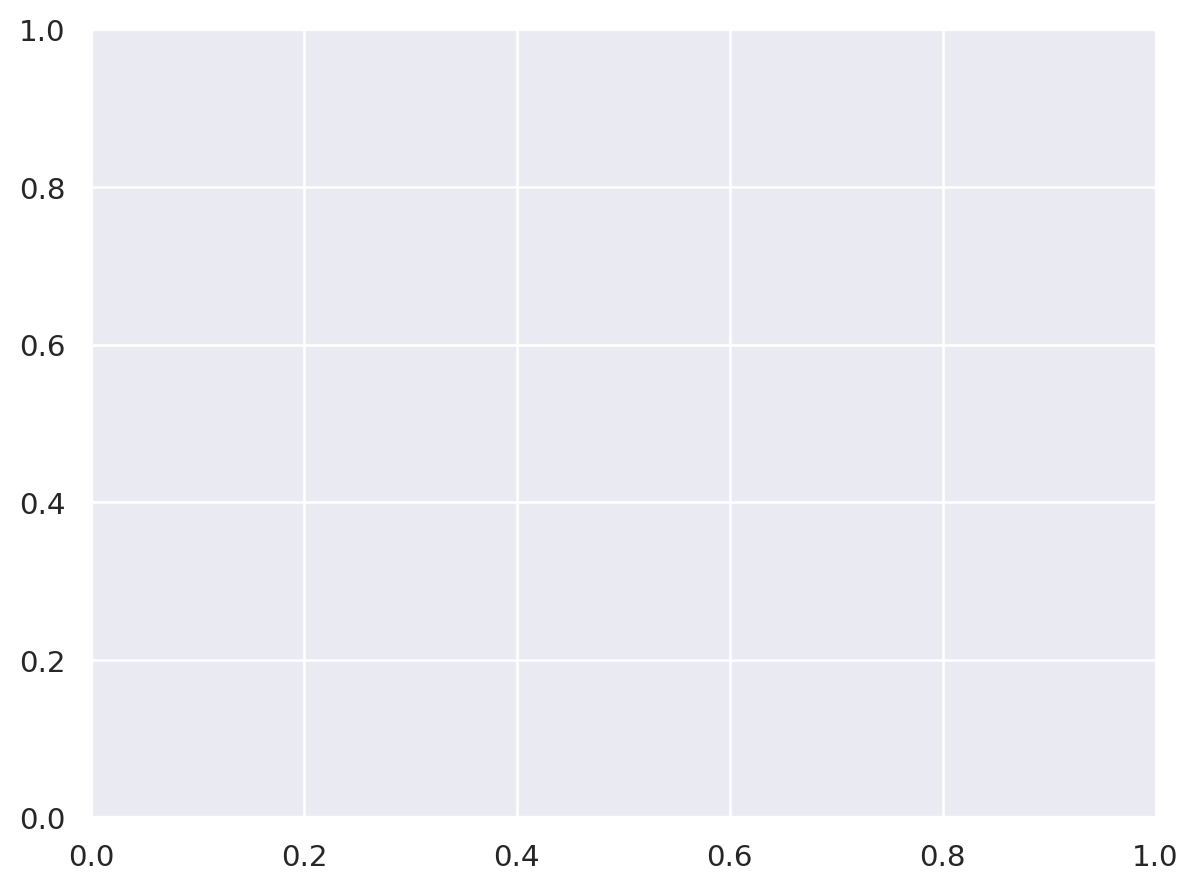

In [ ]:
# Comenzamos con un gráfico vacío
so.Plot()

In [ ]:
# Vamos a utilizar como primer ejemplo un dataset con el índice Dow Jones de las bolsas de Estados Unidos.
dowjones = sns.load_dataset("dowjones") #incluido en seaborn
dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


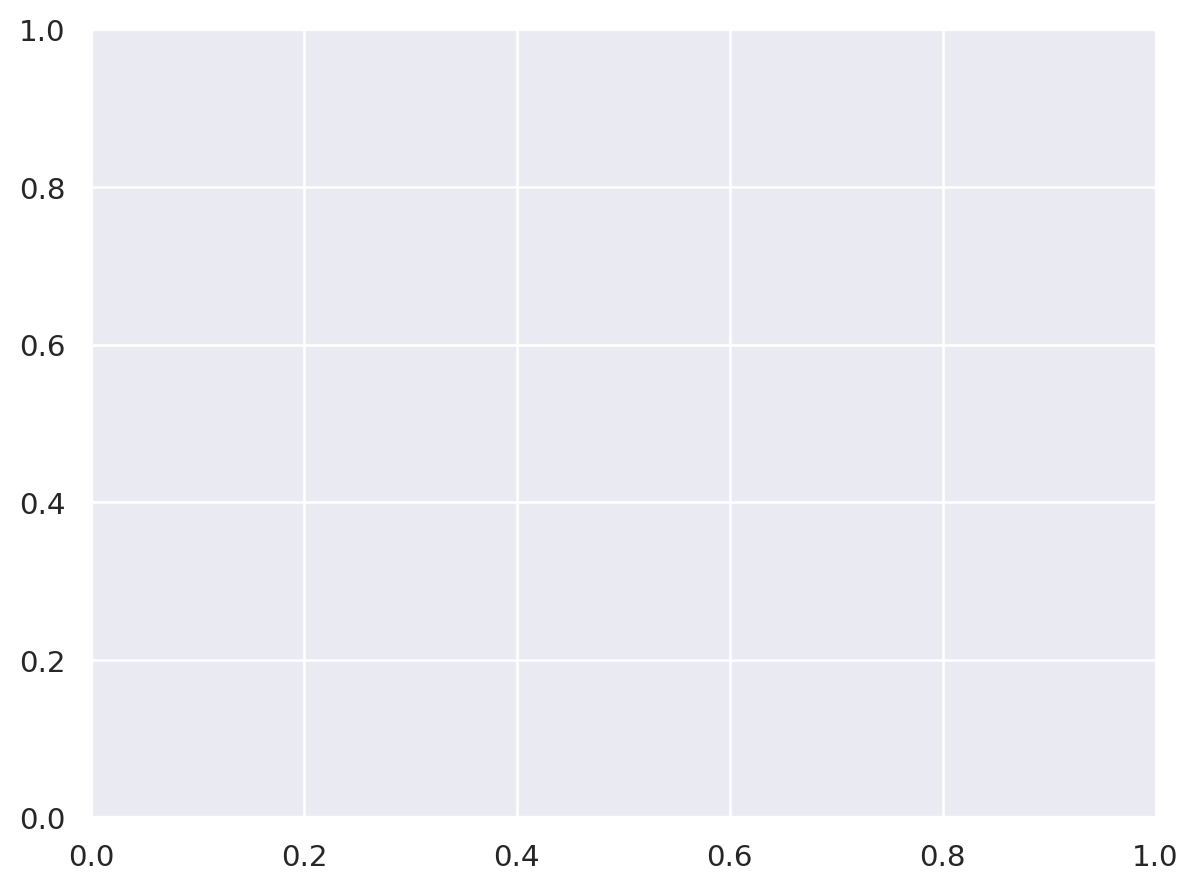

In [ ]:
# Agregamos el conjunto de datos al Plot
so.Plot(data = dowjones)    # No se produce ningún cambio en el gráfico

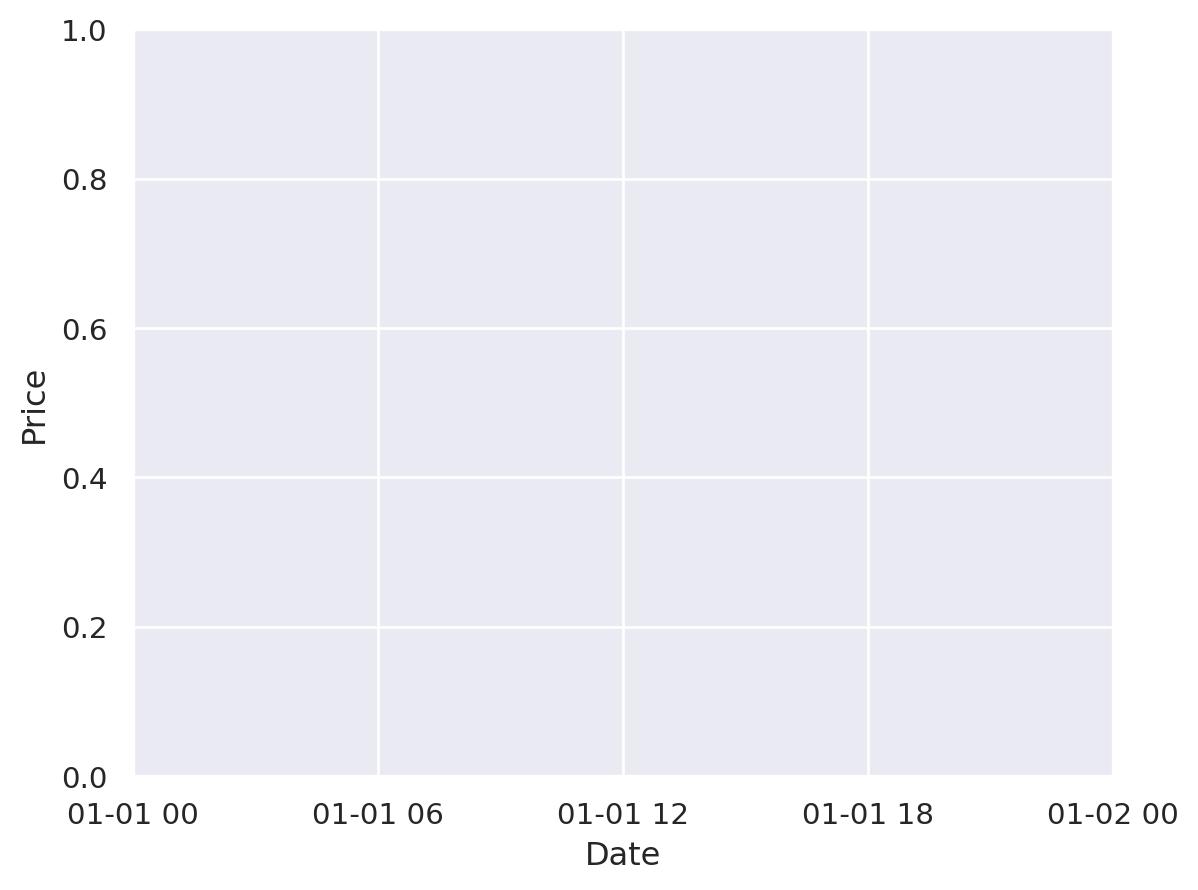

In [ ]:
# Mapeamos la fecha al eje X y el precio al eje Y
so.Plot(data = dowjones, x = "Date", y = "Price") #aun no representa nd q tenga q ver con la info del df

### Gráfico de funciones

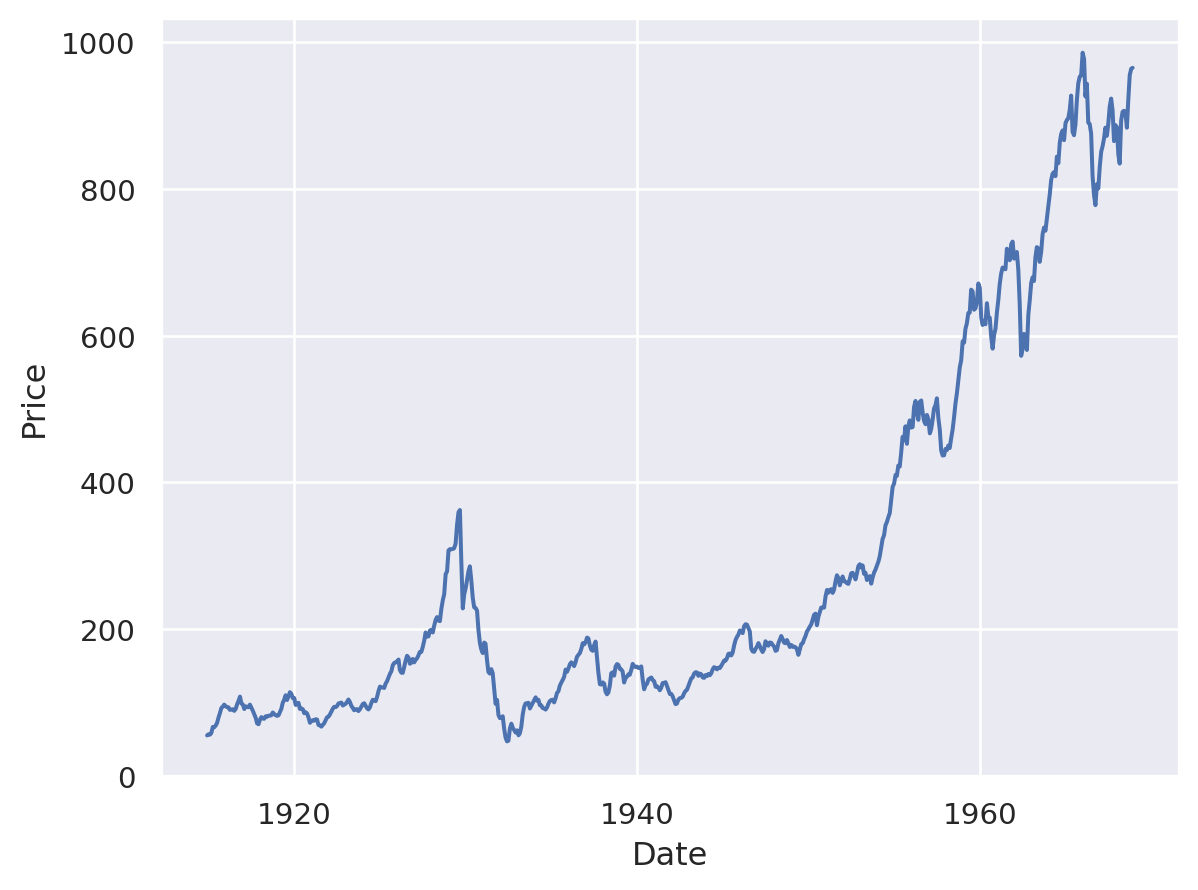

In [ ]:
# Finalmente agregamos una marca, en este caso una curva.
# Usamos paréntesis para poder separar el comando en varias líneas y facilitar la lectura. Pero es una sola línea
(
    so.Plot(data = dowjones, x = "Date", y = "Price")
    .add(so.Line()) #add par agg marcas
)
#esta herramienta line se usa par fun: para cada x se tiene una y

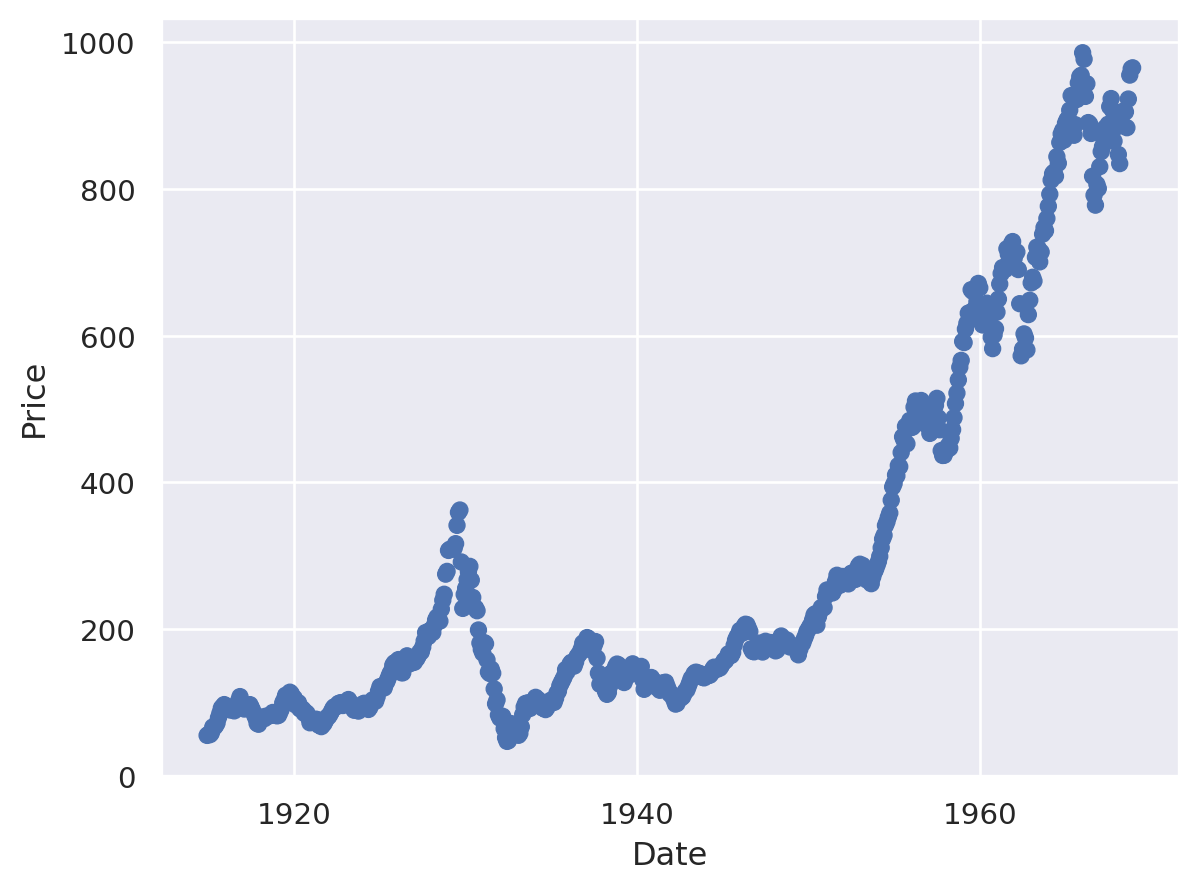

In [ ]:
#puntos
(
    so.Plot(data = dowjones, x = "Date", y = "Price")
    .add(so.Dot())
)

### Gráfico de dispersión (scatter plot)
Utilizamos ahora una base de datos de propinas en restaurants.

Vamos a estudiar qué relación hay entre el valor de la cuenta y la propina que dejan los clientes.

In [ ]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


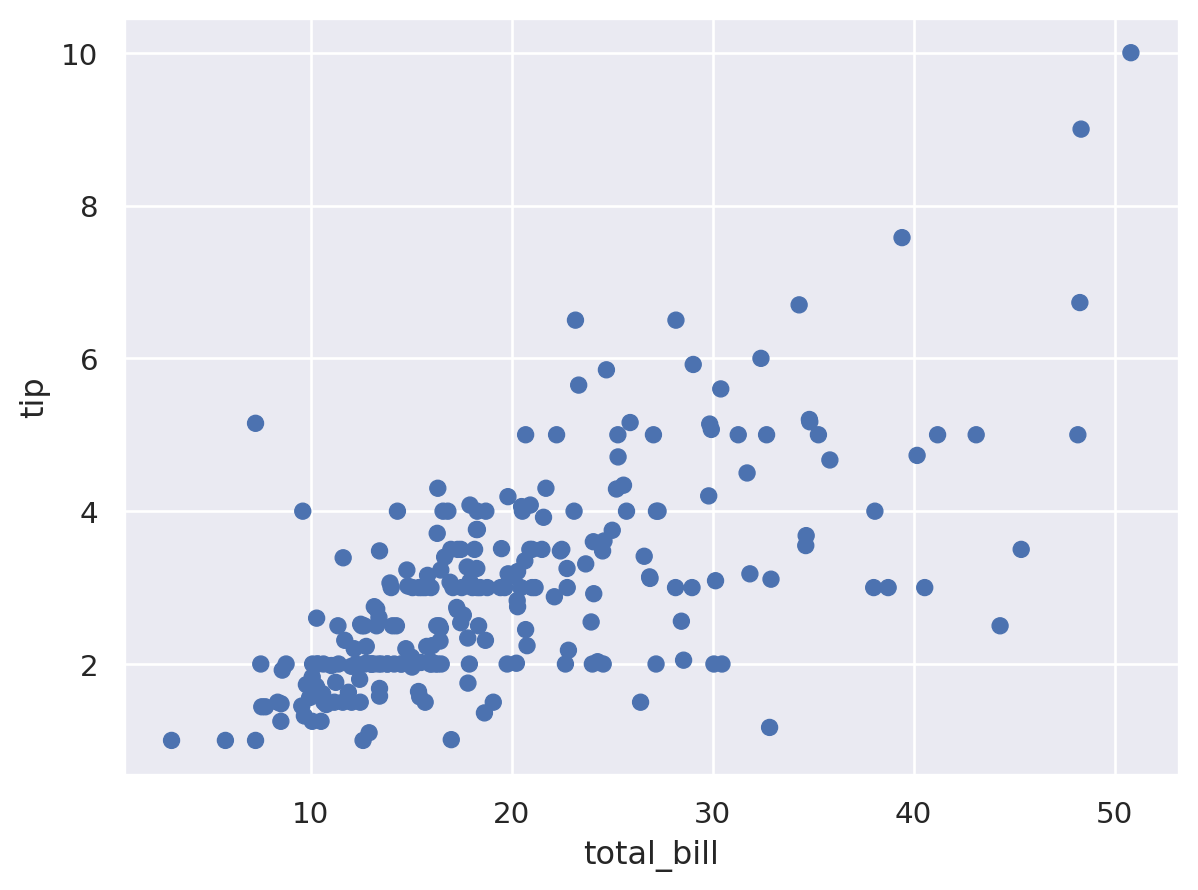

In [ ]:
(
    so.Plot(data = tips, x = "total_bill", y = "tip")
    .add(so.Dot())
)
#mientras + grande la cuenta, + grande el tip

**Pregunta:** ¿tiene sentido para los datos de propinas realizar un gráfico de línea (conectando todos los puntos)? No pq no se cumple q es una fun.

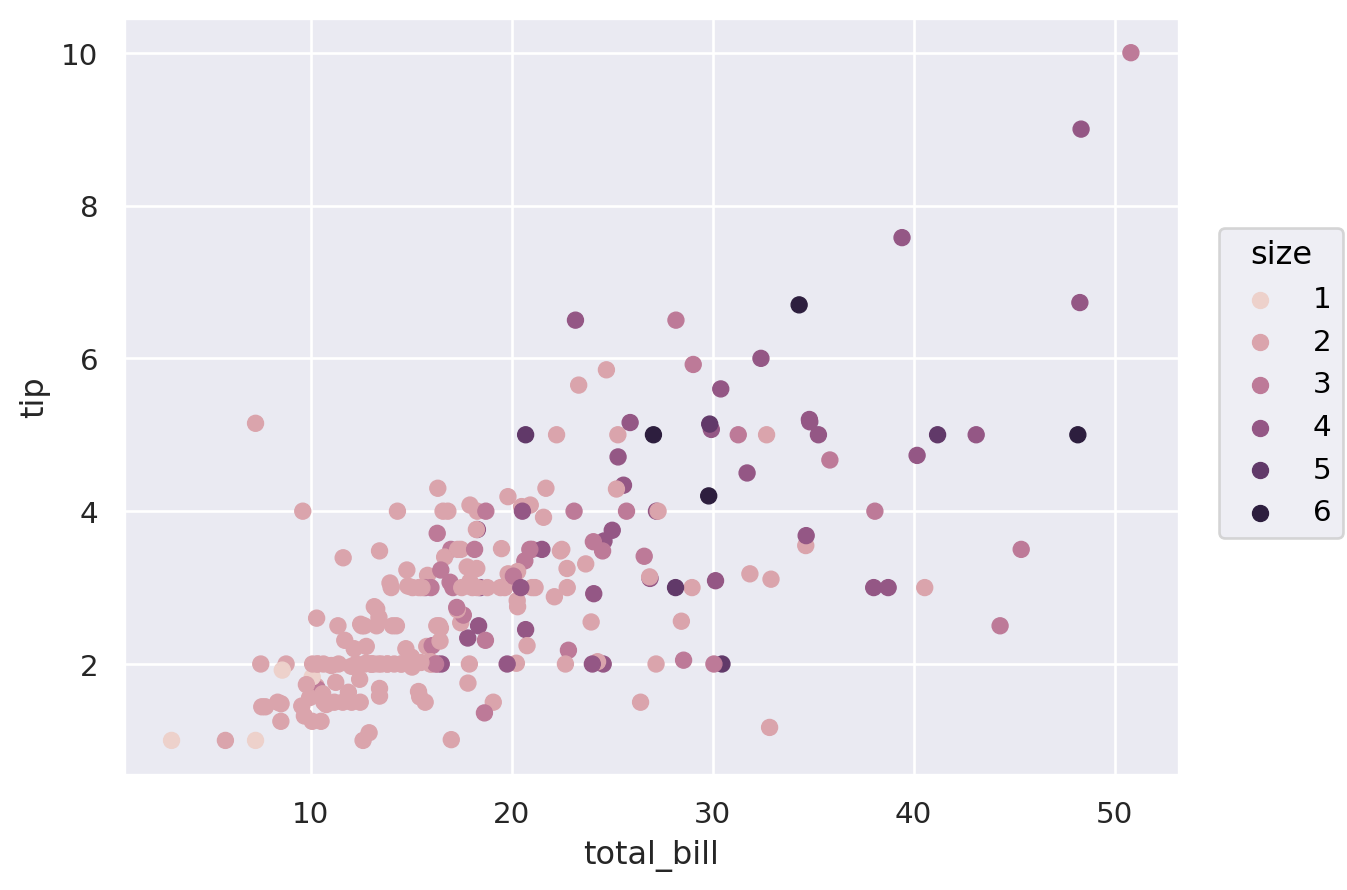

In [ ]:
(
    so.Plot(data = tips, x = "total_bill", y = "tip", color = "size")
    .add(so.Dot())
)

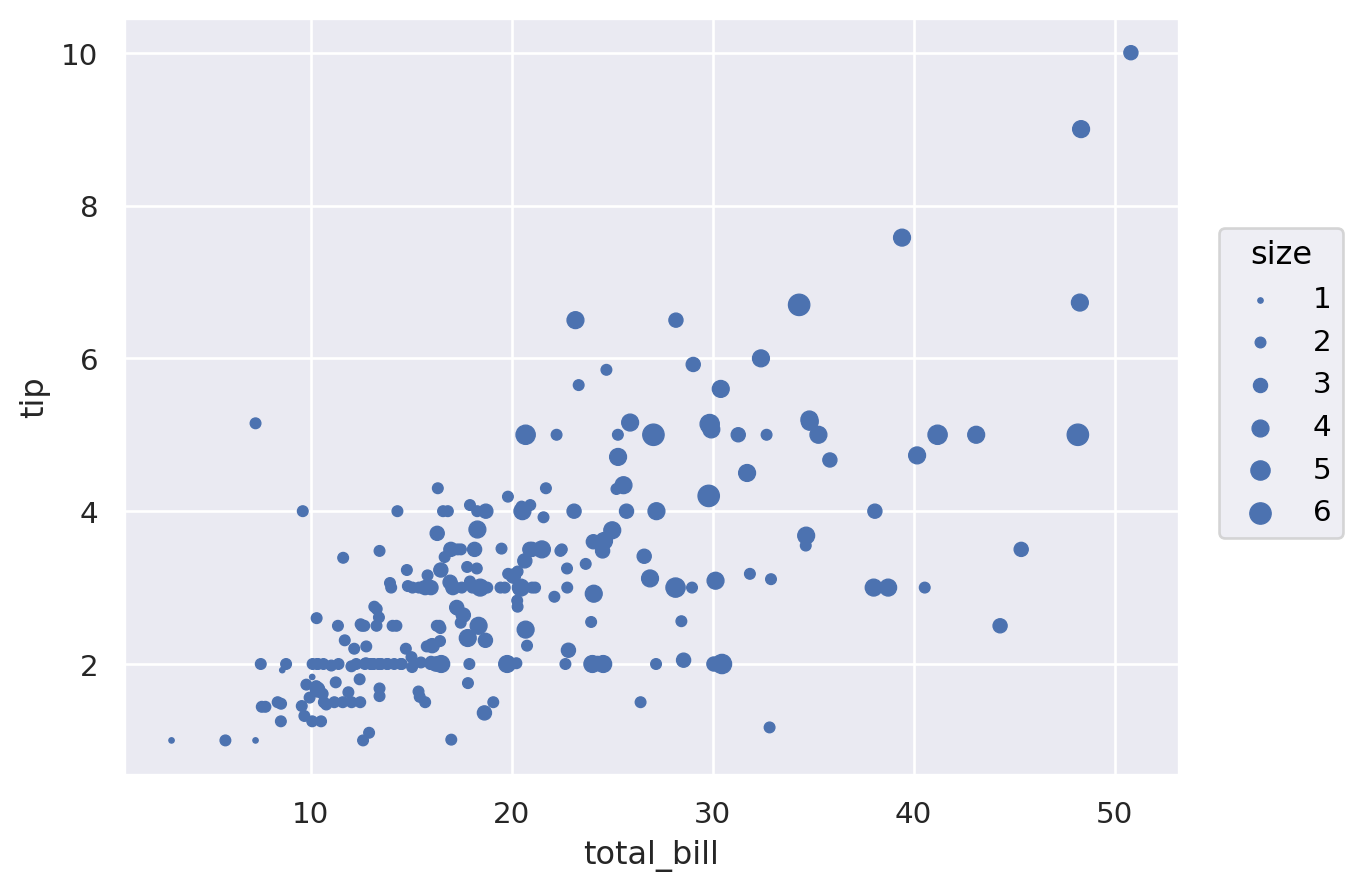

In [ ]:
(
    so.Plot(data = tips, x = "total_bill", y = "tip", pointsize = "size")
    .add(so.Dot())
)

### Gráfico de curvas y puntos?
En algunos casos queremos superponer líneas y puntos.

Utilizamos ahora una base de datos de cantidad de pasajeros mensuales en una aerolínea.

In [ ]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


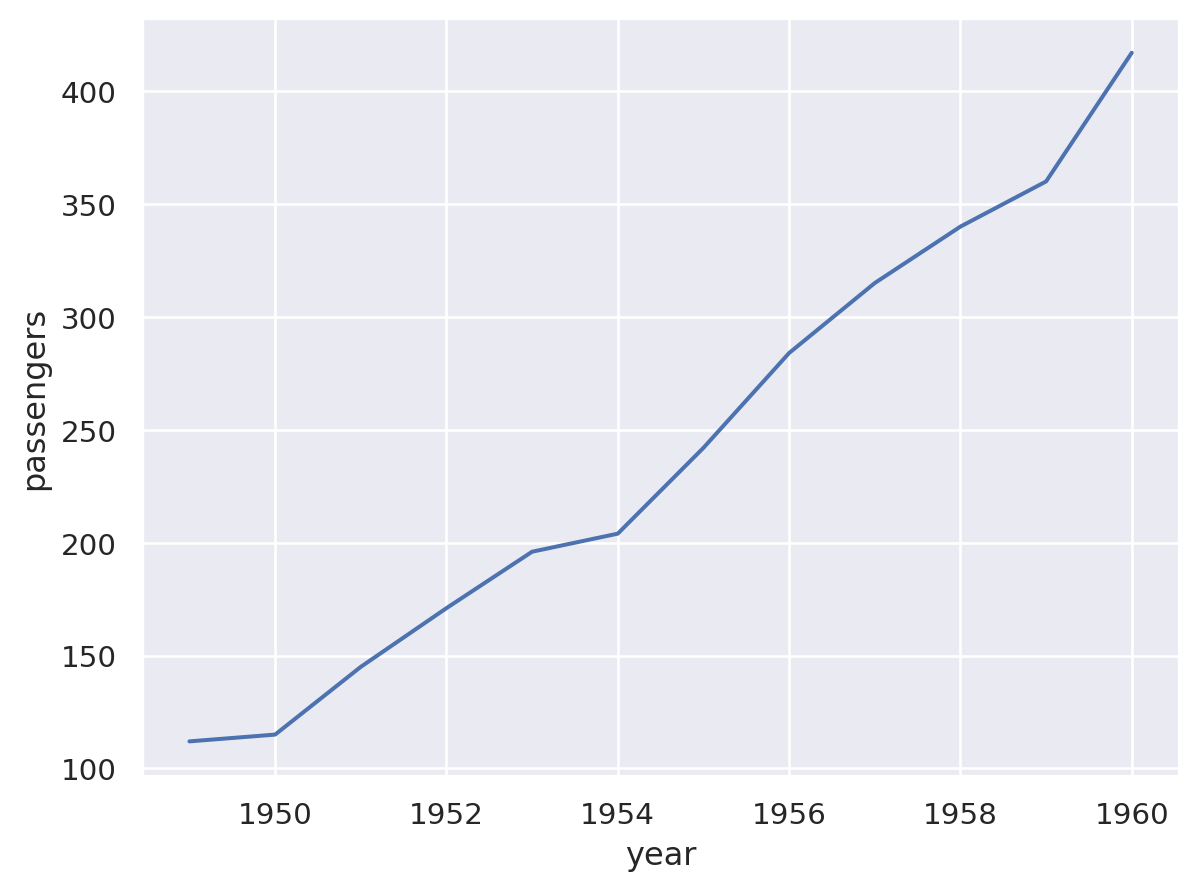

In [ ]:
# Graficamos la curva cantidad de pasajeros en enero de cada año
vuelosEnero = flights[flights.month == "Jan"]
(
    so.Plot(data = vuelosEnero, x = "year", y = "passengers")
    .add(so.Line())
)

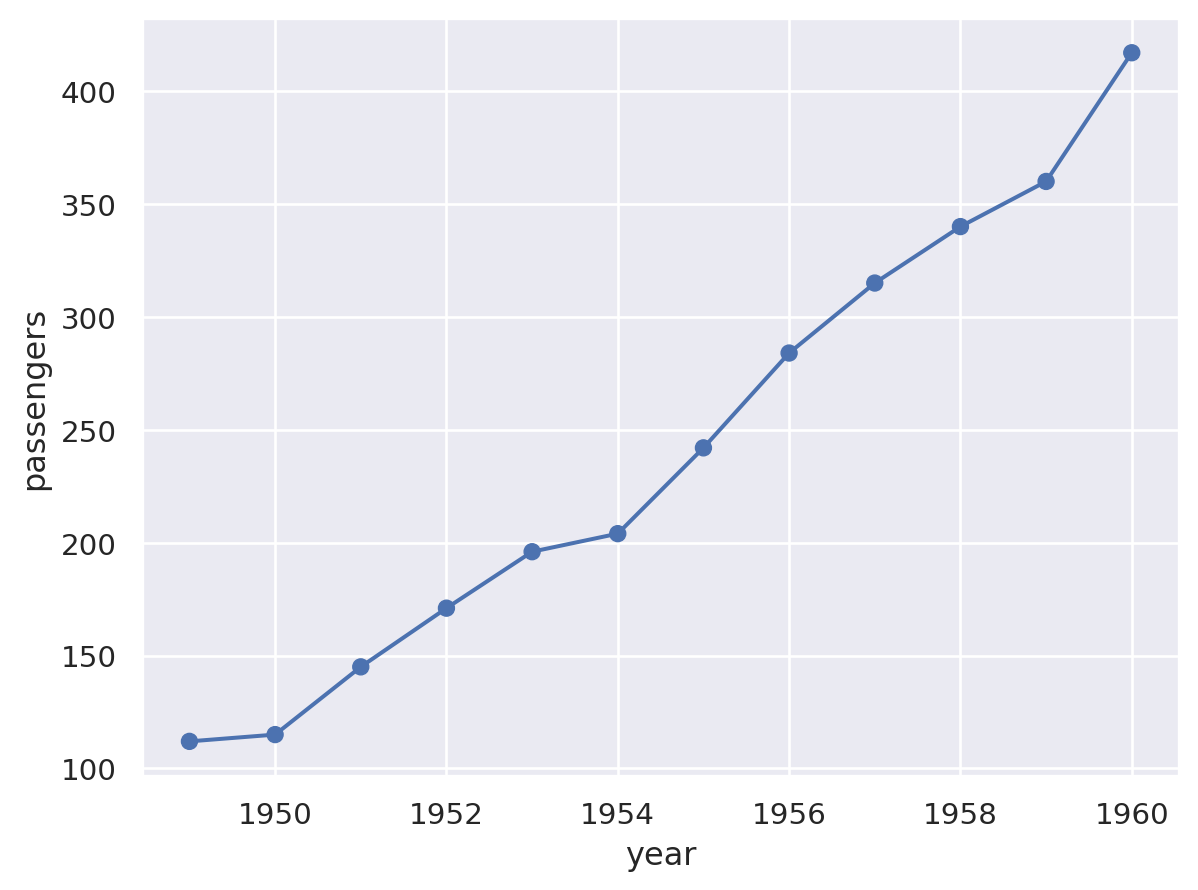

In [ ]:
# Si queremos dibujar también los puntos correspondientes a cada dato...
(
    so.Plot(data = flights[flights.month == "Jan"], x = "year", y = "passengers")
    .add(so.Line())
    .add(so.Dot())
) #tanto line como dot usan la misma info

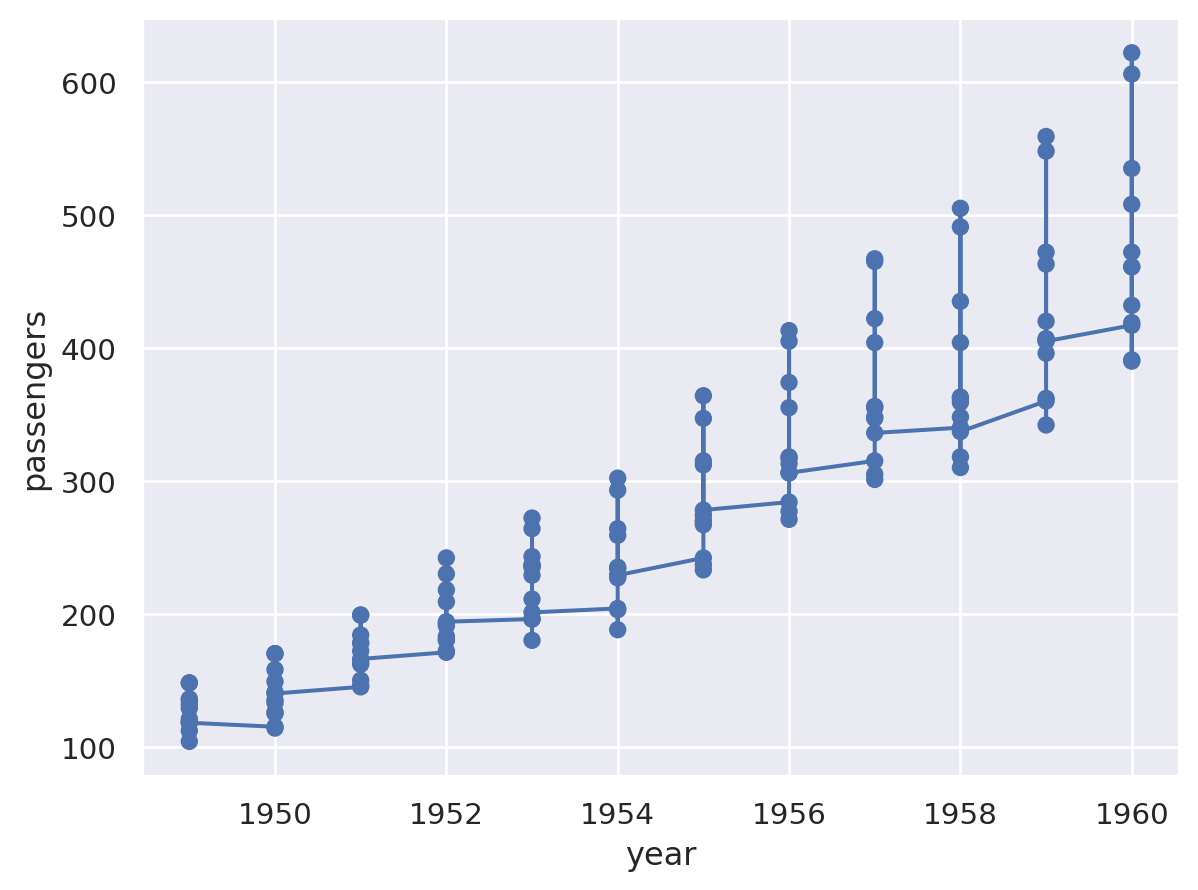

In [ ]:
#agg la info de distintos meses:
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line())
    .add(so.Dot())
)

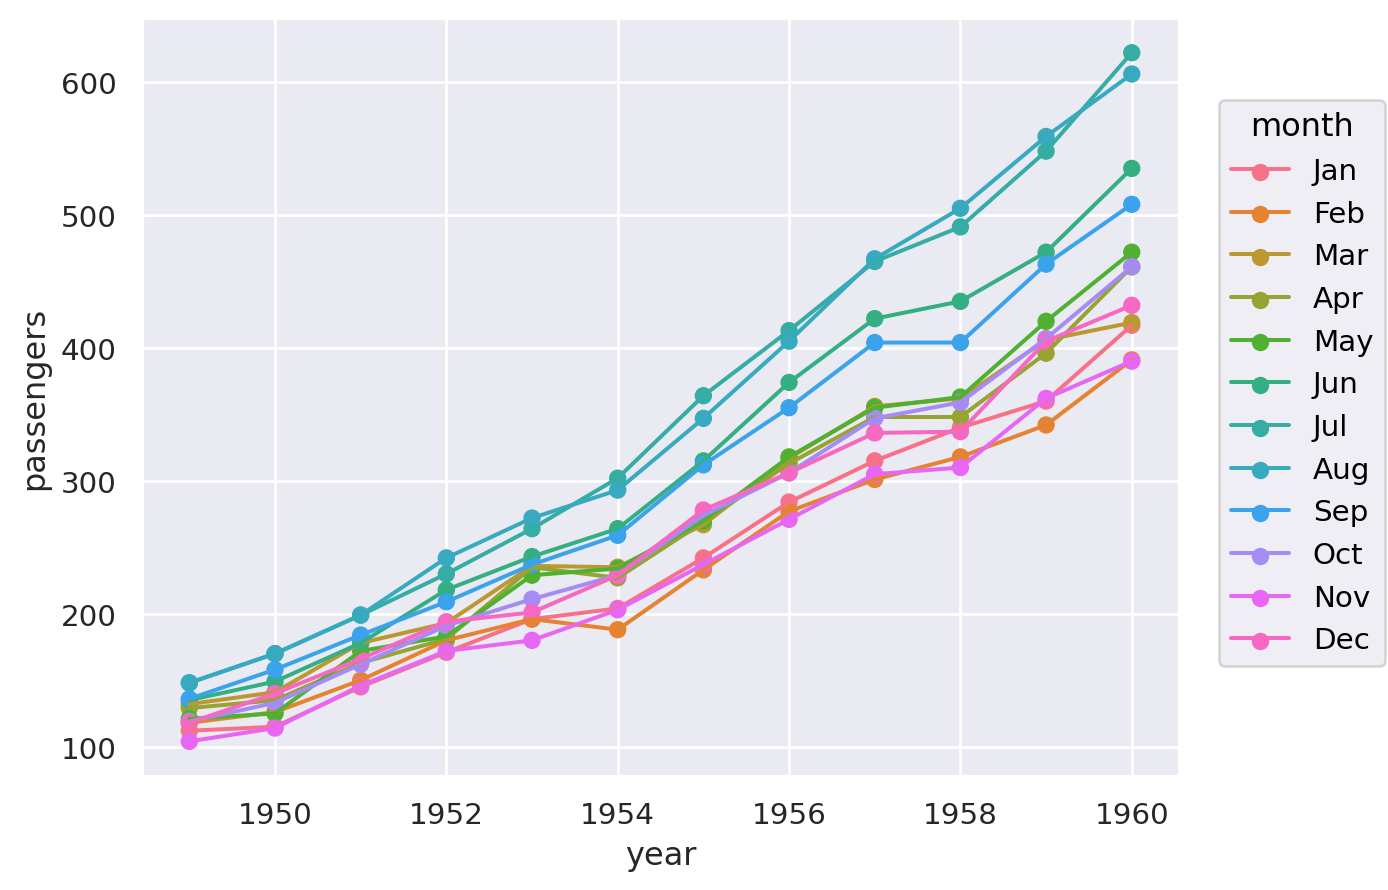

In [ ]:
#con diferentes colores
(
    so.Plot(data = flights, x = "year", y = "passengers", color = "month")
    .add(so.Line())
    .add(so.Dot())
) #con month ya lo div x mes automaticamente

### Datos "agregados"

También podemos "agregar" datos (aggregate = agregar, juntar, resumir, ...)

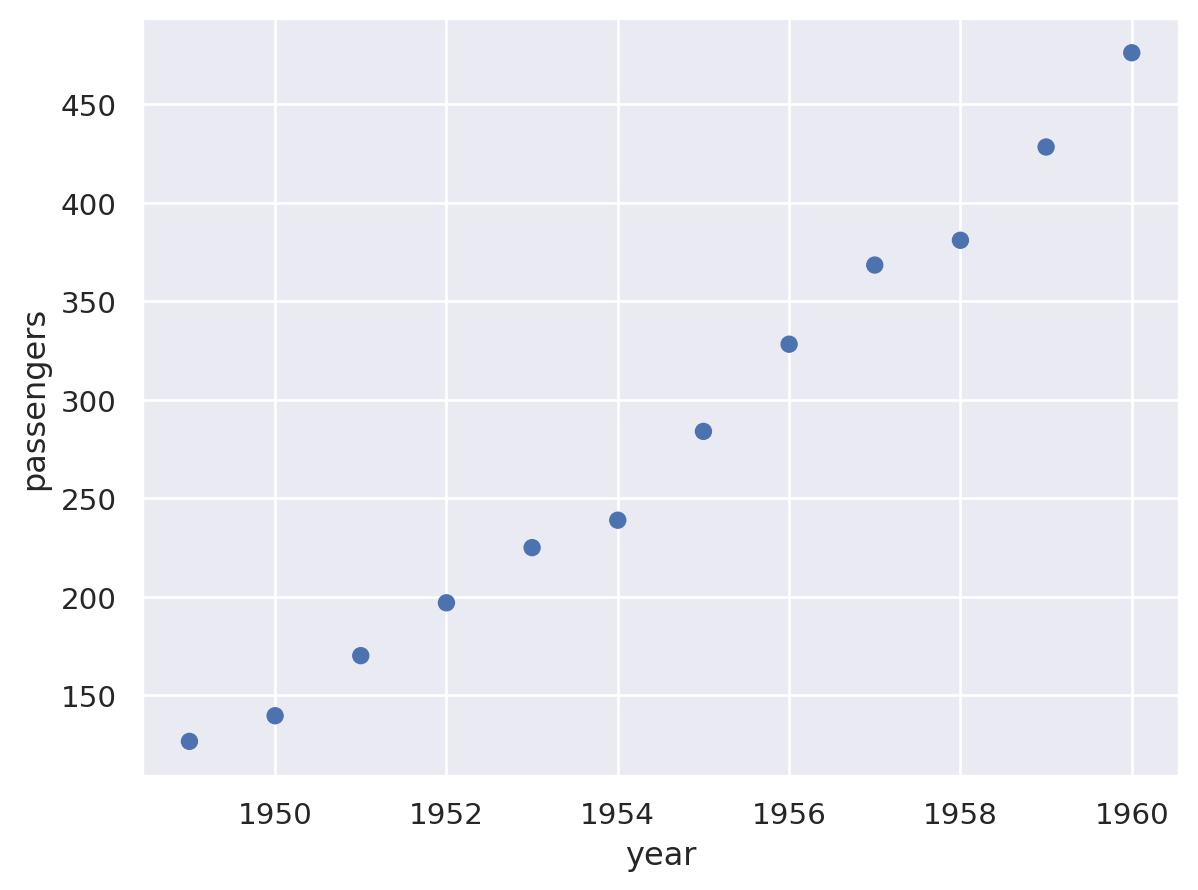

In [ ]:
# Opción 2: agregamos los datos por mes
# Podemos calcularlos previamente utilizando lo que vimos en la práctica 2 (groupby(), sum(), ...)
# o usamos una función para agregar los datos.
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Dot(), so.Agg())  # Usamos .Agg() para agregar los datos. Si no se pone un parametro dentro se calcula la media por default.
)

**AGRUPA LOS VALORES POR X = YEAR Y PARA CADA ANIO:**


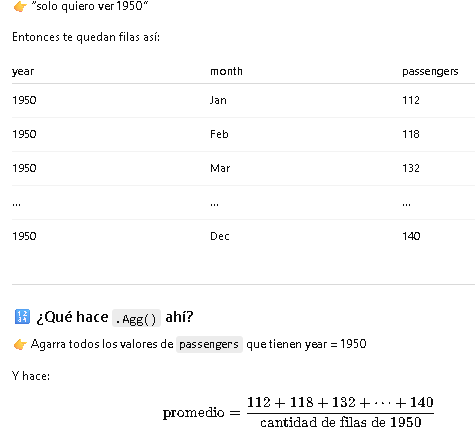

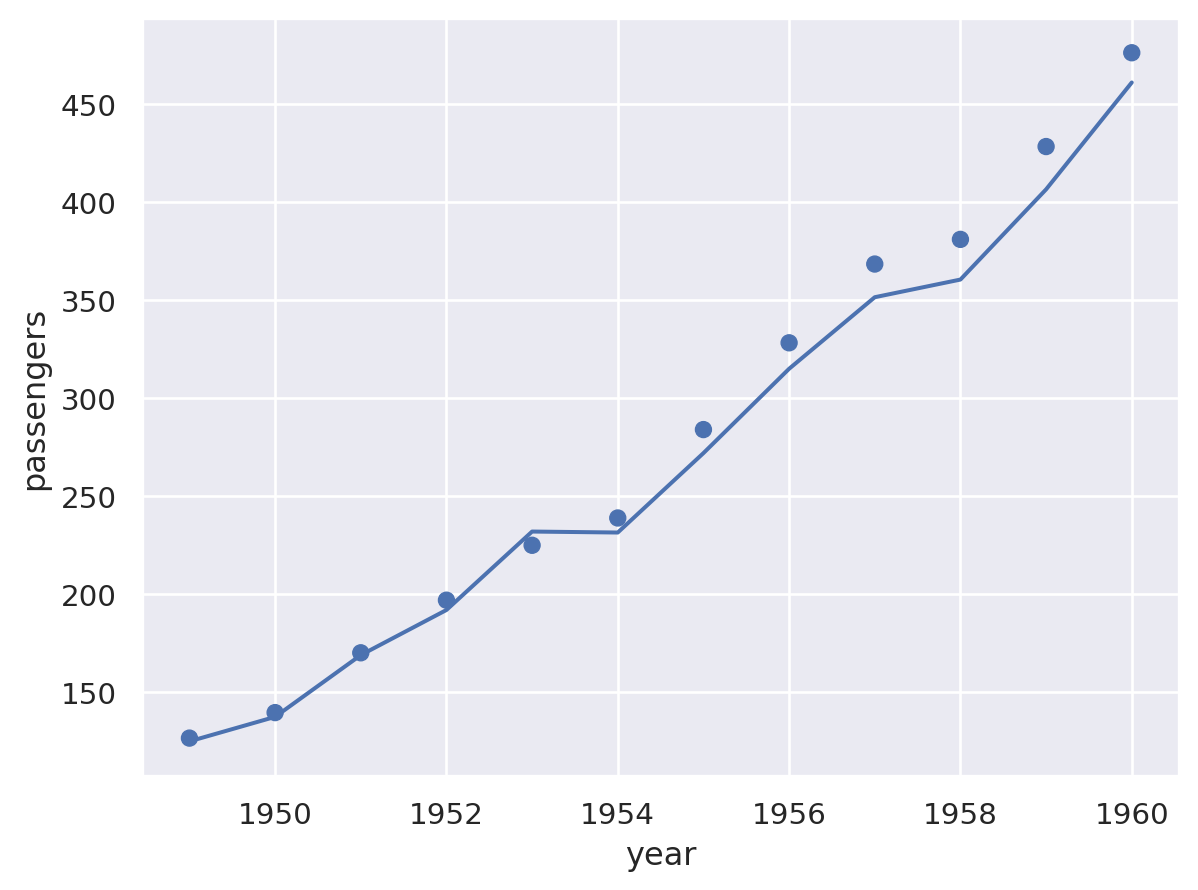

In [ ]:
# Qué valores está graficando? Es la suma??
# Podemos indicar cualquier función de Pandas.Series para agregar los datos
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Dot(), so.Agg("mean")) #vimos como se calculaba la media antes son los puntos
    .add(so.Line(), so.Agg("median"))
)

**QUE HACE MEDIAN:**

Igual que antes:
👉 mirás un año (por ejemplo 1950)
👉 tomás todos los valores de `passengers` de ese año

PERO en vez de promediar:

👉 los ordena y toma el valor del medio

Otro canal común cuando hacemos gráficos de puntos es el tamaño de los puntos.
¿Qué esperamos ver en el siguiente gráfico?

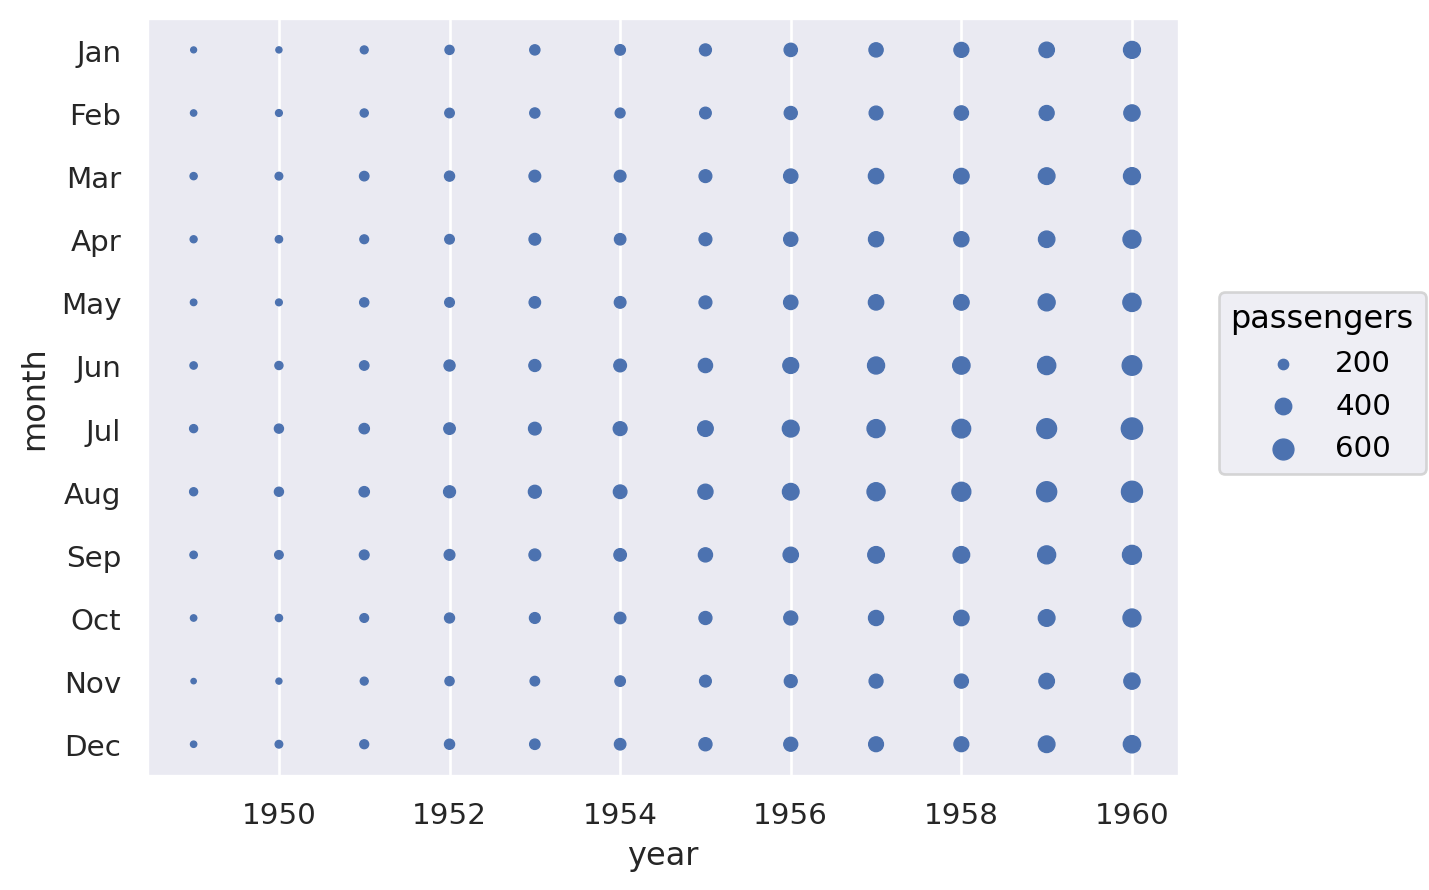

In [ ]:
(
    so.Plot(data = flights, x = "year", y = "month", pointsize = "passengers")
    .add(so.Dot())
)

Más información sobre canales que podemos aplicar a puntos en la página
https://seaborn.pydata.org/tutorial/properties.html

**Ejercicio.**
Reproducir este gráfico utilizando Seaborn Objects.

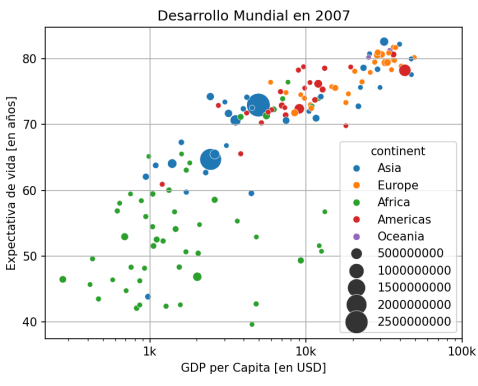

In [4]:
#Vamos a usar los datos de gapminder
%pip install gapminder

In [5]:
from gapminder import gapminder
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


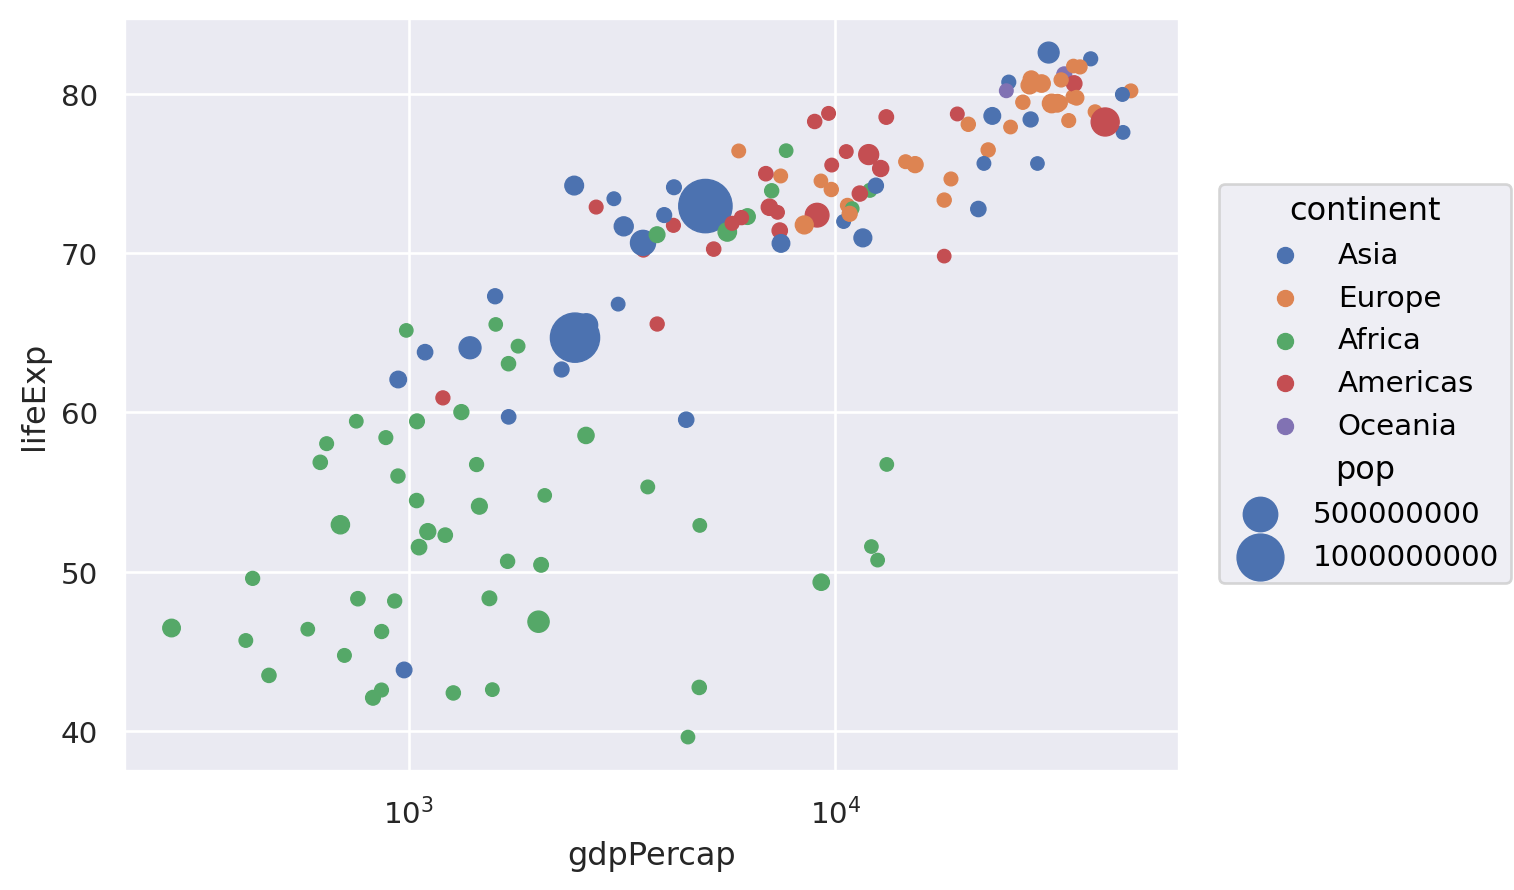

In [8]:
# En el eje X del grafico se usó escala logarítmica, podemos usar esa escala agrendo scale(x = "log")
datos2007 = gapminder[gapminder["year"]==2007]
(
    so.Plot(data = datos2007, x = "gdpPercap", y = "lifeExp", color = "continent", pointsize = "pop")
    .add(so.Dot())
    .scale(x="log", pointsize=(5, 20))  # Escala logaritmica en la variable x y tamaño de puntos entre 5 y 20.
)

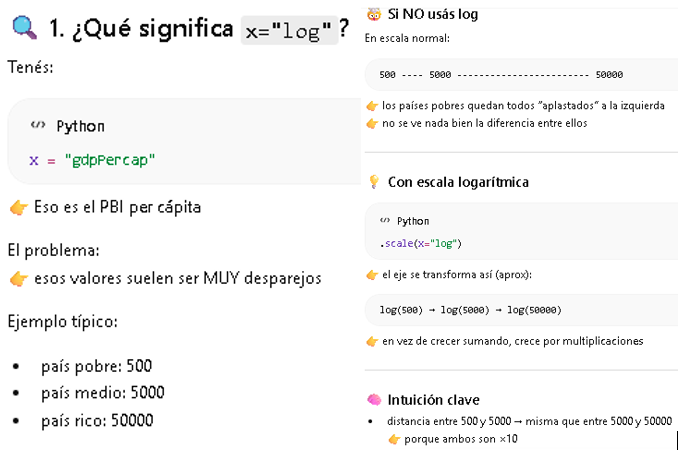

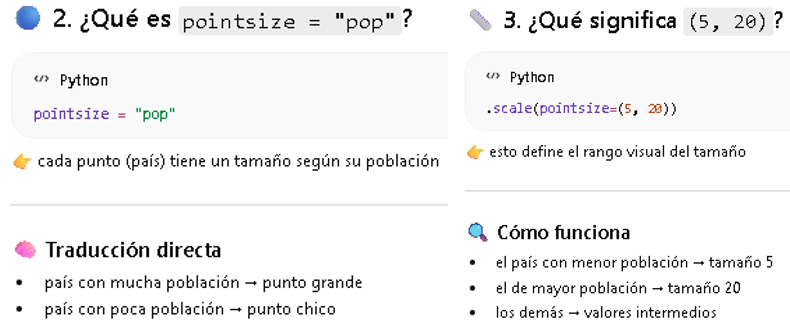

**Ejercicio**

El dataset mpg de Seaborn tiene información sobre la eficiencia (miles per gallon) de distintos modelos de autos.
Realizar un gráfico que permita visualizar como inciden el país de origen **ORIGIN**, el peso del auto **WEIGHT** y los caballos de fuerza **HORSEPOWER** en la eficiencia del auto **MPG**.

**¿Qué conclusiones podemos sacar en base a este gráfico?**


In [11]:
# Cargamos los datos
mpg = sns.load_dataset("mpg")
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


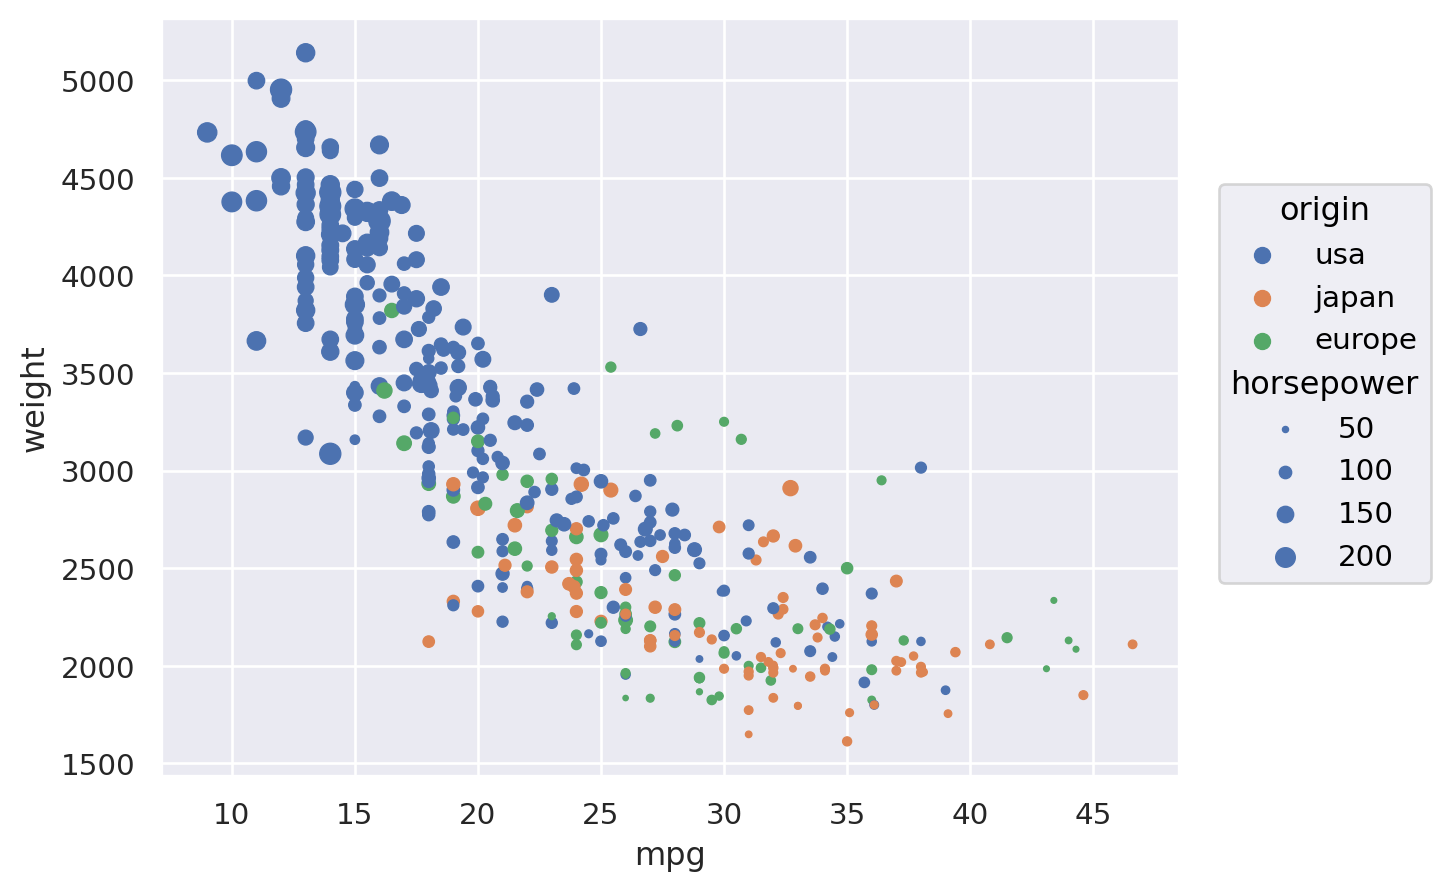

In [14]:
(
    so.Plot(data = mpg, x = "mpg", y = "weight", color = "origin", pointsize = "horsepower")
    .add(so.Dot())
)
#Escogi weight como eje 'y' pq es el que tiene menores similitudes entre valores
#Se puede ver en la grafica que la eficiencia aumenta si:
  #Los carros fueron fabricados en Japon o Europa. Siendo USA los de menor eficiencia.
  #Tiene pocos caballos de fuerza.
  #El carro tiene menos peso.

## Mapeo y asignación por capas ***

In [ ]:
# Podemos asignar una codificación al definir el Plot() y esa codificación para a todas las capas.
(
    so.Plot(data = flights, x = "year", y = "passengers", color = "month")
    .add(so.Line())
    .add(so.Dot())
)

In [ ]:
# O podemos asignar una codificación al agregar una marca y esa codificación se aplica solo en esa capa.
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line(), color = "month")
    .add(so.Dot())
)

In [ ]:
# Si asignamos un pámatetro a la marca Dot() u otra marca,
# no estamos codificando datos sino que asignamos el valor directamente.
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Line(), color = "month")
    .add(so.Dot(color = "red"))
)


**Ejercicio** ¿Que pasa si hacemos `.add(so.Dot(color = "month"))`?

¿Y si hacemos `so.Plot(data = flights, x = "year", y = "passengers", color = "red")`?

La codificación de datos en las coordenadas x e y de las marcas también podemos indicarlas en las capas y codificar distintos datos en distintas capas.

**Notación:** Si utilizamos una palabra entre comillas para algún canal, se interpreta como una variable del DataFrame.
Si lo hacemos sin comillas se interpreta como una variable fuera del DataFrame, podemos usar por ejemplo arrays de numpy o series de pandas.

In [ ]:
# Si queremos comparar la cantidad promedio de vuelos con la cantidad de vuelos en enero...
pasajerosEnero = flights[flights["month"] == "Jan"]["passengers"]
display(pasajerosEnero)

In [ ]:
# Si queremos comparar la cantidad promedio de vuelos con la cantidad de vuelos en enero...
pasajerosEnero = flights[flights["month"] == "Jan"]["passengers"]
(
    so.Plot(data = flights, x = "year")
    .add(so.Line(), ???, y = "passengers") # Promedio anual de pasajeros por mes
    .add(so.Line(color = "red"), y = ???) # Pasajeros en enero
)

## Gráficos de barras

In [ ]:
# Qué hace la marca "barras" (Bars)?
tips = sns.load_dataset("tips")
(
    so.Plot(tips, "total_bill", "tip")
    .add(so.Bar())
)

En el anterior caso no es una buena visualización.

Probamos un ejemplo más sencillo

In [ ]:
personas = pd.DataFrame({'nombre':['Marcos', 'Sofia', 'Andrés'], 'altura':[192, 168,165]})
(
    so.Plot(personas, "nombre", "altura")
    .add(so.Bar())
)

In [ ]:
# La variable x puede también corresponder a valores numéricos discretos.
# Graficamos la cantidad total de vuelos por año.

flights = sns.load_dataset("flights")
flights.head()
(
    so.Plot(data = flights, x = "year", y = "passengers")
    .add(so.Bar(), so.Agg("sum"))
)

## Gráfico de barras de frecuencias
El último gráfico de barras vemos la cantidad de pasajero en función del año.
En ese caso las cantidades por mes ya estaban calculadas y solo las sumamos.

Cuando tenemos todos los datos individuales, podemos agregarlos para hacer un gráfico de barras usando el método `hist`.

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

### Frecuencias de una variable categórica

Tenemos una base de datos con información de píngüinos y queremos saber cuántos pingüinos hay en cada isla.

No tenemos en la tabla ningún dato de población por isla, tenemos un renglon por cada pingüino, y para cada pingüino sabemos a qué isla pertenece.

In [ ]:
# Podemos contarlos primero usando funciones de Pandas...
#???  ## EJERCICIO
#display(pinguinos_por_isla)

# Lo hacemos a mano para no resolver el ejercicio.
islas = ['Biscoe', 'Dream', 'Torgersen']
poblacion = [168, 124, 52]
pinguinos_por_isla = pd.Series(poblacion, index=islas)
type(pinguinos_por_isla)

In [ ]:
pinguinos_por_isla.name = "poblacion"
pinguinos_por_isla.index.name = "isla"
display(pinguinos_por_isla)

In [ ]:
# Esto no funciona, no podemos usar una series de Pandas como data
(
    so.Plot(data = pinguinos_por_isla, x = "isla", y = "poblacion")
    .add(so.Bar())
)

**Pregunta:** ¿Podemos usar so.Plot() sin un DataFrame?

Sí, no necesariamente tenemos que indicar data, x e y al definir el Plot().

Podemos usar series de Pandas o arrays para x e y.

In [ ]:
# Pero podemos indicar series para x e y, y no especificar ninguna DataFrame
(
#    so.Plot(x = pinguinos_por_isla.???, y = ???)
#    .add(so.Bar())
)

### Frecuencias usando `so.Hist()`
Ahora usamos las funciones de so.Plot() para agregar los datos y realizar el histograma.

No necesitamos nosotros contar "a mano" cuántos pingüinos hay en cada isla.

In [ ]:
# Repasamos los datos
penguins.head()

In [ ]:
# La variable "island" es una variable categórica, con tres valores distintos.
penguins["island"].unique()

Contamos cuántas veces se repite cada uno de los tres valores.

In [ ]:
# Hay que asignar una variable y?
(
    so.Plot(data = penguins, x = "island")
    .add(so.Bar(), so.Hist())
)

### Histogramas (frecuencias de una variable numérica)

**Ejercicio.** Realizar en el cuaderno un histograma de cuatro barras para los siguientes datos:
$$
edades = \{20,28,18,10,50,55,70,75,80,76,82\}
$$

Verificar el gráfico en Python.


In [ ]:
edades = pd.Series([20,28,18,10,50,55,70,75,80,76,82])
(
    so.Plot(x = edades)
    .add(so.Bar(), so.Hist(bins = 4))
)

Para histogramas de una variable continua es más común que no haya tanto espacio entre las barras.

Para eso usamos `Bars` en lugar de `Bar`.

In [ ]:
edades = pd.Series([20,28,18,10,50,55,70,75,80,76,82])
(
    so.Plot(x = edades)
    .add(so.Bars(), so.Hist(bins = 4))
)

### Histrogramas y distribución de una variable

Los histogramas nos sirven para analizar la distribución de valores observados de una variable.

**Ejemplo:** ¿Cuánto pesa un pingüino?

In [ ]:
# Queremos ver cuántos pingüinos hay en distintos rangos de peso.
(
    so.Plot(data = penguins, x = "body_mass_g")
    .add(so.Bars(), so.Hist())
)

In [ ]:
# Podemos cambiar la cantidad de intervalos.
# Si tomamos muy pocos intervalos no vamos a poder distinguir los valores.
# Si tomamos muchos intervalos, van a quedar muy desagregados y será difícil comparar distintos intervalos.
(
    so.Plot(data = penguins, x = "body_mass_g")
    .add(so.Bars(), so.Hist(bins = 40))
)

**Ejercicio** En el datasets de propinas, agregar una columna de "porcentaje" y realizar un histograma que permita visualizar cuánto dejan usualmente los comensales de propina.

## Box plot

### Ejercicio
Realizar en el cuaderno un grafico boxplot para los siguientes datos:
$$
respuestas = \{10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 105\}
$$

Verificar el gráfico en Python.

En Seaborn Objects no tenemos la opción de realizar box plots. Podemos hacerlos utilizando `seaborn.boxplot()`. Los parámetros a pasar son similares.


In [ ]:
respuestas = pd.Series([10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 105])

# Verificamos primero el cálculo de cuartiles
display(respuestas.quantile(.25, interpolation = "midpoint"))  # Primer cuantil
display(respuestas.quantile(.50))   # Segundo cuantil
display(respuestas.quantile(.75, interpolation = "midpoint"))  # Tercer cuantil

In [ ]:
# Ahora realizamos el boxplot
(
    sns.boxplot(x = respuestas)
    .set(xlabel='Respuestas')
)
plt.show()

### Ejercicio.
1. Si agregamos a los datos un valor 110, será marcado como outlier en el gráfico?
2. Si cambiamos el ultimo valor (105) a un valor mas grande, a partir de qué valor pasaría a ser outlier en el gráfico?

Verificarlo en Python.

In [ ]:
respuestas = pd.Series([10, 15, 20, 24, 30, 50, 54, 60, 62, 70, 100, 135])
respuestas.name = "Respuestas"
sns.boxplot(x = respuestas)
plt.show()

In [ ]:
# Los mismos datos del histograma anterior del peso de los pingüinos,
# podemos representarlos en un BoxPlot
fig, ax =plt.subplots(1,2)  # Utilizamos este código para crear una grilla de dos gráficos.
fig.set_figwidth(12)
(
    so.Plot(data = penguins, x = "body_mass_g")
    .add(so.Bars(), so.Hist())
    .on(ax[0]).plot()  # Colocamos el histograma en la primera casilla de la grilla.
)
sns.boxplot(penguins, x="body_mass_g", ax = ax[1])    # Colocamos el boxplot en la segunda casilla de la grilla.
plt.show()



In [ ]:
# Si queremos comparar distintos grupos de datos, podemos hacer boxplots para cada grupo
# Los mismos datos del histograma anterior, los representamos en un BoxPlot
sns.boxplot(data = penguins, x="species", y = "body_mass_g")
plt.show()

**Ejercicio.** ¿Qué conclusiones podemos sacar en base a este gráfico?

### Cantidad de pasajeros por año

In [ ]:
# También podemos representar la información de vuelos por mes utilizando boxplots.
sns.boxplot(data = flights, x = "year", y = "passengers")

### MPG

1) En el dataset mpg, utilizar gráficos BoxPlot para estudiar la eficiencia de los vehículos en función del lugar de origen. ¿Qué conclusiones puede obtener?

2) Utilizar gráficos BoxPlot para comparar la eficiencia de los autos segun el año del modelo, utilizando solo auto modelo 1970, 1975 y 1980.